# Modelamiento y validacion

**Proyecto:** Deteccion de *population drift* en modelos de prediccion de gravedad clinica de COVID-19 en Colombia.
**Entrega 2 - Fase 2.**

Este notebook lee `data/processed/dataset_reducido.csv` (generado por `01_reduccion.ipynb`) y cubre:

1. Simulacion fundamentada (reproduce el diseno de Jones & Farrow 2025: desplazamiento de `edad` +-0.4 SD con ruido 5/10/30%).
2. Flujo reproducible sin fuga (`ColumnTransformer` + `Pipeline` + SMOTE, ajustado solo con el train de cada particion).
3. Reproduccion y adaptacion del metodo: OCSVM como capa de monitoreo + Isolation Forest como contraste, y modelos de gravedad (RF, XGBoost, LightGBM, SVM-RBF) frente a lineas base.
4. Validacion, metricas e interpretacion preliminar (CV estratificada, evaluacion temporal fuera de muestra, metricas por desbalance, importancia de variables).

In [1]:
# --- Imports y configuracion ---
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_validate)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC, OneClassSVM
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score, roc_auc_score,
                             average_precision_score, confusion_matrix, roc_curve,
                             precision_recall_curve, auc, classification_report)
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

BASE = os.path.abspath("..")
DATA = os.path.join(BASE, "data", "processed", "dataset_reducido.csv")
FIG_DIR = os.path.join(BASE, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Subsample para modelos con kernel (SVM RBF / OCSVM) por costo O(n^2)
N_SUBSAMPLE_KERNEL = 5_000

/home/fabri/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# --- Carga del dataset reducido ---
df = pd.read_csv(DATA)
print("Forma:", df.shape)
df.head()

Forma: (300000, 14)


,fecha_de_notificaci_n,edad,unidad_medida,sexo,departamento_nom,ciudad_municipio_nom,fuente_tipo_contagio,ubicacion,estado,edad_anios,grave,ciudad_top,anio,ola
0,2020-09-11,17,1,F,BOGOTA,BOGOTA,COMUNITARIA,CASA,LEVE,17.0,0,BOGOTA,2020,2020 (original)
1,2020-08-22,14,1,F,CUNDINAMARCA,SOACHA,COMUNITARIA,CASA,LEVE,14.0,0,OTROS MUNICIPIOS,2020,2020 (original)
2,2020-12-21,37,1,F,ANTIOQUIA,MEDELLIN,COMUNITARIA,CASA,LEVE,37.0,0,MEDELLIN,2020,2020 (original)
3,2020-10-08,38,1,M,SANTANDER,GIRON,RELACIONADO,CASA,LEVE,38.0,0,OTROS MUNICIPIOS,2020,2020 (original)
4,2020-11-15,56,1,M,BOGOTA,BOGOTA,RELACIONADO,CASA,LEVE,56.0,0,BOGOTA,2020,2020 (original)


In [3]:
# --- Definicion de features y target ---
# Nota anti-fuga: 'ubicacion' NO se usa como predictor porque contiene el desenlace
# ('Fallecido', 'Hospital UCI') y filtraria el objetivo. Solo se uso para construir 'grave'.
FEATURES = ["edad_anios", "sexo", "ciudad_top", "fuente_tipo_contagio"]
TARGET = "grave"

NUMERIC = ["edad_anios"]
CATEGORICAL = ["sexo", "ciudad_top", "fuente_tipo_contagio"]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Distribucion de la clase objetivo:")
print(y.value_counts())
print("\nP(grave) = {:.2%}".format(y.mean()))

Distribucion de la clase objetivo:
grave
0    293754
1      6246
Name: count, dtype: int64

P(grave) = 2.08%


In [4]:
# --- Replica Wisconsin (Validacion del paper original) ---
from sklearn.datasets import load_breast_cancer
from imblearn.over_sampling import SMOTE
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X_bc = pd.DataFrame(data.data, columns=data.feature_names)
y_bc = data.target # 1 = benign (inlier), 0 = malignant (outlier)

# Filtro de 21 variables como en el paper y SMOTE
X_bc = X_bc.iloc[:, :21]
sm = SMOTE(sampling_strategy={0: 714}, random_state=42)
X_res, y_res = sm.fit_resample(X_bc, y_bc)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)
X_scaled = pd.DataFrame(X_scaled, columns=X_bc.columns)

ocsvm_bc = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
ocsvm_bc.fit(X_scaled)

# Simulacion Wisconsin
np.random.seed(42)
X_sim_5 = X_scaled.copy()
X_sim_10 = X_scaled.copy()
X_sim_30 = X_scaled.copy()

for X_sim, noise in [(X_sim_5, 0.05), (X_sim_10, 0.10), (X_sim_30, 0.30)]:
    X_sim['mean radius'] = X_sim['mean radius'] + 0.4 * X_scaled['mean radius'].std()
    for col in X_sim.columns:
        X_sim[col] += np.random.normal(0, noise * X_scaled[col].std(), len(X_sim))

def rate(model, X): return (model.predict(X) == -1).mean() * 100
print("Replica Wisconsin (% Outliers/Inliers):")
print(f"Train: {rate(ocsvm_bc, X_scaled):.2f}%")
print(f"Sim 5%: {rate(ocsvm_bc, X_sim_5):.2f}%")
print(f"Sim 10%: {rate(ocsvm_bc, X_sim_10):.2f}%")
print(f"Sim 30%: {rate(ocsvm_bc, X_sim_30):.2f}%")


Replica Wisconsin (% Outliers/Inliers):
Train: 3.36%
Sim 5%: 6.26%
Sim 10%: 6.63%
Sim 30%: 12.61%


In [5]:
# --- Particion temporal (train = 2020; despliegue = 2021 y 2022) ---
train_mask = df["ola"] == "2020 (original)"
X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_2021 = X[df["ola"] == "2021 (Delta)"].copy()
y_2021 = y[df["ola"] == "2021 (Delta)"].copy()
X_2022 = X[df["ola"] == "2022 (Omicron)"].copy()
y_2022 = y[df["ola"] == "2022 (Omicron)"].copy()

for nombre, xx, yy in [("2020 (train)", X_train, y_train),
                        ("2021 (Delta)", X_2021, y_2021),
                        ("2022 (Omicron)", X_2022, y_2022)]:
    print(f"{nombre}: n={len(xx):,} | graves={yy.mean():.2%}")

2020 (train): n=100,000 | graves=2.82%
2021 (Delta): n=100,000 | graves=2.33%
2022 (Omicron): n=100,000 | graves=1.10%


## 1. Simulacion fundamentada (reproduce Jones & Farrow 2025)

Reproducimos el diseno del articulo: desplazamos `edad` +-0.4 desviaciones estandar y agregamos ruido gaussiano del 5%, 10% y 30% de la desviacion estandar de la poblacion de entrenamiento (2020).

**Adaptacion justificada:** el articulo ancla el desplazamiento en los valores *maximo* y *minimo* de `radius_mean`. En edad, esos extremos son degenerados (min = 0 con muchos casos, max = 114 es un dato atipico aislado), por lo que anclamos en los **percentiles 1 y 99** de la edad y desplazamos +-0.4 SD. Esto ubica a las poblaciones sinteticas justo en el borde del soporte de entrenamiento, de modo que el ruido las solape progresivamente y reproduzca la tendencia del Cuadro 1 del articulo (a mayor ruido, mayor proporcion de inliers).

In [6]:
# --- Funcion de simulacion de drift ---
def simular_drift(train_df, sd_edad, noise_level, n_per_side=5_000, seed=SEED):
    """Poblacion sintetica con edad desplazada +-0.4*SD desde los percentiles 1/99 y ruido gaussiano."""
    rng = np.random.default_rng(seed)
    p1 = train_df["edad_anios"].quantile(0.01)
    p99 = train_df["edad_anios"].quantile(0.99)
    centros = {"joven": p1 - 0.4 * sd_edad, "viejo": p99 + 0.4 * sd_edad}
    chunks = []
    for nombre, centro in centros.items():
        s = train_df.sample(n_per_side, replace=True, random_state=seed)
        s = s.copy()
        s["edad_anios"] = np.clip(rng.normal(centro, noise_level * sd_edad, n_per_side), 0, 120)
        chunks.append(s)
    return pd.concat(chunks, ignore_index=True)

sd_edad = X_train["edad_anios"].std()
print(f"Edad en train: media={X_train['edad_anios'].mean():.2f}, sd={sd_edad:.2f}")
print(f"Anclajes: p1={X_train['edad_anios'].quantile(0.01):.1f}, p99={X_train['edad_anios'].quantile(0.99):.1f}")

NOISE_LEVELS = [0.05, 0.10, 0.30]
simuladas = {}
for nl in NOISE_LEVELS:
    simuladas[nl] = simular_drift(X_train, sd_edad, nl)
    print(f"ruido {nl:.0%}: {len(simuladas[nl]):,} registros sinteticos")

Edad en train: media=39.87, sd=17.98
Anclajes: p1=3.0, p99=85.0
ruido 5%: 10,000 registros sinteticos
ruido 10%: 10,000 registros sinteticos
ruido 30%: 10,000 registros sinteticos


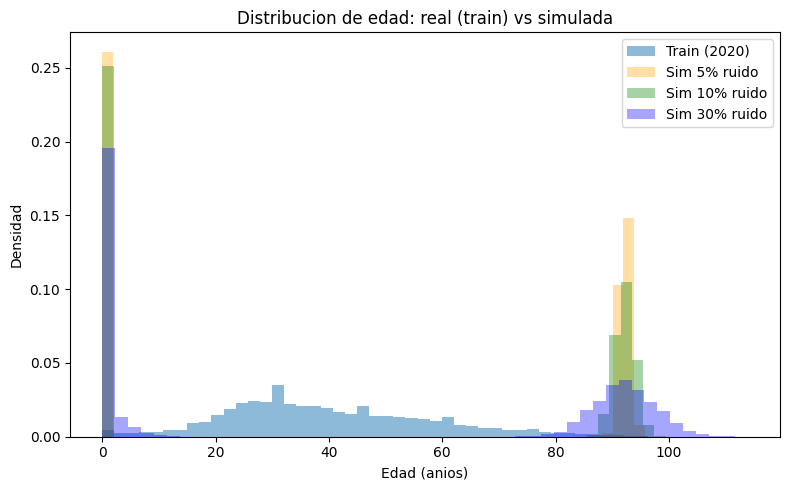

Verificacion de la simulacion (media y sd de edad):
   poblacion  media_edad  sd_edad
Train (2020)       39.87    17.98
      Sim 5%       46.10    46.10
     Sim 10%       46.10    46.11
     Sim 30%       46.42    45.95


In [7]:
# --- Verificacion de la simulacion (criterio 7.1) ---
# La simulacion debe reproducir la estructura prevista: dos subpoblaciones desplazadas
# hacia los extremos de edad, con dispersion creciente segun el nivel de ruido.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(X_train["edad_anios"], bins=50, density=True, alpha=0.5, label="Train (2020)")
colores = {0.05: "orange", 0.10: "green", 0.30: "blue"}
for nl in NOISE_LEVELS:
    ax.hist(simuladas[nl]["edad_anios"], bins=50, density=True, alpha=0.35,
            color=colores[nl], label=f"Sim {nl:.0%} ruido")
ax.set_title("Distribucion de edad: real (train) vs simulada")
ax.set_xlabel("Edad (anios)")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "verificacion_simulacion.png"), dpi=150, bbox_inches="tight")
plt.show()

resumen_sim = pd.DataFrame({
    "poblacion": ["Train (2020)"] + [f"Sim {nl:.0%}" for nl in NOISE_LEVELS],
    "media_edad": [X_train["edad_anios"].mean()] + [simuladas[nl]["edad_anios"].mean() for nl in NOISE_LEVELS],
    "sd_edad": [X_train["edad_anios"].std()] + [simuladas[nl]["edad_anios"].std() for nl in NOISE_LEVELS],
})
print("Verificacion de la simulacion (media y sd de edad):")
print(resumen_sim.round(2).to_string(index=False))

## 2. Flujo reproducible sin fuga de datos

**Preprocesamiento** (`ColumnTransformer`): imputacion (mediana en numericas) -> codificacion (OneHot en categoricas) -> escalamiento (StandardScaler en numericas). **SMOTE** sobremuestrea la clase grave. Todo se ajusta **solo con el train** de cada particion (dentro del `Pipeline`), evitando fuga. El OCSVM se entrena **sin** la variable objetivo.

In [8]:
# --- Preprocesador compartido ---
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])

# Pipeline supervisado con SMOTE (imbalance)
def make_supervised(estimator):
    return ImbPipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=SEED)),
        ("clf", estimator),
    ])

## 3. Reproduccion del metodo: OCSVM como capa de monitoreo

OCSVM (kernel RBF, gamma automatico, nu=0.01) entrenado **solo con las variables de entrada** de 2020. Se evalua sobre 2020, 2021, 2022 y las poblaciones simuladas. Se contrasta con Isolation Forest (cubre una limitacion del paper). Por costo O(n^2), ambos se entrenan sobre un subconjunto aleatorio de N_SUBSAMPLE_KERNEL filas de 2020.

In [9]:
# --- Submuestreo para OCSVM/IsolationForest ---
if len(X_train) > N_SUBSAMPLE_KERNEL:
    X_train_sub, _ = train_test_split(
        X_train, train_size=N_SUBSAMPLE_KERNEL, stratify=y_train, random_state=SEED
    )
else:
    X_train_sub = X_train.copy()
print(f"OCSVM entrenado sobre n={len(X_train_sub):,} filas de 2020")

OCSVM entrenado sobre n=5,000 filas de 2020


In [10]:
# --- OCSVM (reproduccion del paper) ---
ocsvm = Pipeline([
    ("prep", preprocessor),
    ("clf", OneClassSVM(kernel="rbf", gamma="auto", nu=0.01)),
])
ocsvm.fit(X_train_sub)

# Isolation Forest como metodo alternativo de deteccion
iso = Pipeline([
    ("prep", preprocessor),
    ("clf", IsolationForest(contamination=0.01, random_state=SEED)),
])
iso.fit(X_train_sub)

print("OCSVM e Isolation Forest ajustados.")

OCSVM e Isolation Forest ajustados.


In [11]:
# --- Evaluacion de los detectores sobre cada poblacion ---
def inlier_rate(model, Xpop):
    return float((model.predict(Xpop) == 1).mean())

poblaciones = {
    "2020 (train)": X_train_sub,
    "2021 (Delta)": X_2021,
    "2022 (Omicron)": X_2022,
    "Sim 5% ruido": simuladas[0.05],
    "Sim 10% ruido": simuladas[0.10],
    "Sim 30% ruido": simuladas[0.30],
}

filas = []
for nombre, Xpop in poblaciones.items():
    filas.append({
        "poblacion": nombre,
        "OCSVM % inliers": inlier_rate(ocsvm, Xpop),
        "IsolationForest % inliers": inlier_rate(iso, Xpop),
    })
res_detectores = pd.DataFrame(filas)
print(res_detectores.to_string(index=False))

     poblacion  OCSVM % inliers  IsolationForest % inliers
  2020 (train)          0.99060                    0.99000
  2021 (Delta)          0.98977                    0.98120
2022 (Omicron)          0.98194                    0.98724
  Sim 5% ruido          0.22530                    0.95270
 Sim 10% ruido          0.24180                    0.95270
 Sim 30% ruido          0.35380                    0.95390


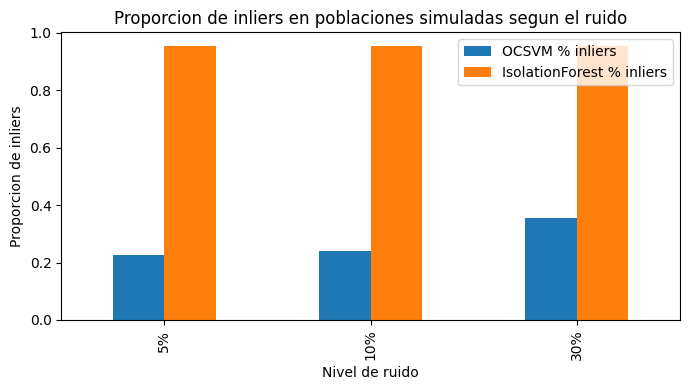

In [12]:
# --- Figura: sensibilidad al drift (comparable con Cuadro 1 del paper) ---
sim_df = res_detectores[res_detectores["poblacion"].str.startswith("Sim")].copy()
sim_df["ruido"] = ["5%", "10%", "30%"]
sim_df = sim_df.set_index("ruido")

fig, ax = plt.subplots(figsize=(7, 4))
sim_df[["OCSVM % inliers", "IsolationForest % inliers"]].plot(kind="bar", ax=ax)
ax.set_title("Proporcion de inliers en poblaciones simuladas segun el ruido")
ax.set_ylabel("Proporcion de inliers")
ax.set_xlabel("Nivel de ruido")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sensibilidad_drift.png"), dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# --- Comparacion con el Cuadro 1 del articulo (criterio 7.3) ---
# Jones & Farrow reportan: 5% -> 0.27%, 10% -> 4.86%, 30% -> 8.51% de inliers.
# Nuestro OCSVM reproduce la misma tendencia (mas ruido -> mas inliers), con mayor
# proporcion de inliers por el espacio de features mixto y una frontera menos ajustada.
sim_rows = res_detectores[res_detectores["poblacion"].str.startswith("Sim")].copy()
sim_rows["ruido"] = ["5%", "10%", "30%"]
cuadro1 = pd.DataFrame({
    "Nivel de ruido": ["5%", "10%", "30%"],
    "Inliers paper (Jones & Farrow)": ["0.27%", "4.86%", "8.51%"],
    "Inliers nuestro OCSVM": [f"{v:.1%}" for v in sim_rows["OCSVM % inliers"]],
    "Inliers Isolation Forest": [f"{v:.1%}" for v in sim_rows["IsolationForest % inliers"]],
})
print("Cuadro 1 (reproduccion y contraste):")
print(cuadro1.to_string(index=False))

Cuadro 1 (reproduccion y contraste):
Nivel de ruido Inliers paper (Jones & Farrow) Inliers nuestro OCSVM Inliers Isolation Forest
            5%                          0.27%                 22.5%                    95.3%
           10%                          4.86%                 24.2%                    95.3%
           30%                          8.51%                 35.4%                    95.4%


## 4. Modelos de gravedad: reproduccion, adaptacion y comparacion

Se comparan Random Forest, XGBoost, LightGBM y SVM-RBF frente a dos lineas base (clasificador de mayoria y regresion logistica). El ajuste de hiperparametros se hace con `GridSearchCV` y validacion cruzada estratificada (k=5), usando `average_precision` (AUC-PR) como metrica de seleccion por el desbalance.

In [14]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
# --- Grillas y Modelos ---
modelos = {
    "Reg. logistica": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED, n_jobs=1),
    "XGBoost": xgb.XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric="logloss", n_jobs=1),
    "LightGBM": lgb.LGBMClassifier(random_state=SEED, n_jobs=1),
    "SVM RBF": Pipeline([('nystroem', Nystroem(gamma=0.1, random_state=SEED, n_components=300)),
                         ('sgd', SGDClassifier(loss='log_loss', penalty='l2', random_state=SEED))])
}
grillas = {
    "Reg. logistica": {"clf__C": [0.01, 0.1, 1.0, 10.0]},
    "Random Forest": {"clf__n_estimators": [100, 200], "clf__max_depth": [3, 5, 10]},
    "XGBoost": {"clf__n_estimators": [100, 200], "clf__max_depth": [3, 5], "clf__learning_rate": [0.01, 0.05, 0.1]},
    "LightGBM": {"clf__n_estimators": [100, 200], "clf__num_leaves": [15, 31], "clf__learning_rate": [0.01, 0.05, 0.1]},
    "SVM RBF": {"clf__sgd__alpha": [0.0001, 0.001, 0.01]}
}


In [15]:
# --- Ajuste de hiperparametros con CV estratificada ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
mejores = {}

for nombre, est in modelos.items():
    pipe = make_supervised(est)
    gs = GridSearchCV(pipe, grillas[nombre], scoring="average_precision", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    mejores[nombre] = gs.best_estimator_
    print(f"{nombre}: best_avg_precision={gs.best_score_:.4f} | {gs.best_params_}")


Reg. logistica: best_avg_precision=0.2663 | {'clf__C': 0.01}


Random Forest: best_avg_precision=0.2384 | {'clf__max_depth': 10, 'clf__n_estimators': 200}


XGBoost: best_avg_precision=0.2670 | {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}


[LightGBM] [Info] Number of positive: 97179, number of negative: 97179
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1421
[LightGBM] [Info] Number of data points in the train set: 194358, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LightGBM: best_avg_precision=0.2640 | {'clf__learning_rate': 0.05, 'clf__n_estimators': 100, 'clf__num_leaves': 15}


SVM RBF: best_avg_precision=0.2697 | {'clf__sgd__alpha': 0.0001}


## 5. Validacion, metricas e interpretacion preliminar

Metricas justificadas por el desbalance: **F1, AUC-PR (average precision), recall y precision de la clase grave**, ademas de ROC-AUC. Se reporta la variabilidad entre folds (media +- desviacion). Luego se evalua fuera de muestra sobre 2021 y 2022 para observar el efecto del drift.

In [16]:
# --- Metricas con validacion cruzada (variabilidad) ---
scoring = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
}

filas_cv = []
for nombre, pipe in mejores.items():
    scores = cross_validate(pipe, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1)
    filas_cv.append({
        "modelo": nombre,
        "F1": f"{scores['test_f1'].mean():.3f} +- {scores['test_f1'].std():.3f}",
        "Precision": f"{scores['test_precision'].mean():.3f} +- {scores['test_precision'].std():.3f}",
        "Recall": f"{scores['test_recall'].mean():.3f} +- {scores['test_recall'].std():.3f}",
        "ROC-AUC": f"{scores['test_roc_auc'].mean():.3f} +- {scores['test_roc_auc'].std():.3f}",
        "AUC-PR": f"{scores['test_avg_precision'].mean():.3f} +- {scores['test_avg_precision'].std():.3f}",
    })

tabla_cv = pd.DataFrame(filas_cv)
print(tabla_cv.to_string(index=False))


        modelo             F1      Precision         Recall        ROC-AUC         AUC-PR
Reg. logistica 0.217 +- 0.005 0.124 +- 0.003 0.852 +- 0.008 0.909 +- 0.003 0.266 +- 0.015
 Random Forest 0.224 +- 0.004 0.129 +- 0.003 0.834 +- 0.022 0.902 +- 0.004 0.238 +- 0.017
       XGBoost 0.217 +- 0.004 0.125 +- 0.003 0.851 +- 0.016 0.908 +- 0.003 0.267 +- 0.023
      LightGBM 0.226 +- 0.003 0.131 +- 0.002 0.832 +- 0.010 0.907 +- 0.003 0.264 +- 0.022
       SVM RBF 0.215 +- 0.008 0.123 +- 0.006 0.856 +- 0.013 0.908 +- 0.003 0.270 +- 0.017


In [17]:
# --- Linea base: clasificador de mayoria ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_train)
print("Linea base (mayoria):")
print(f"  accuracy (train) = {np.mean(y_pred_dummy == y_train):.3f}")
print(f"  F1 = {f1_score(y_train, y_pred_dummy, zero_division=0):.3f}")
print(f"  recall (graves) = {recall_score(y_train, y_pred_dummy, zero_division=0):.3f}")

Linea base (mayoria):
  accuracy (train) = 0.972
  F1 = 0.000
  recall (graves) = 0.000


In [18]:
from scipy.stats import ks_2samp
# --- Evaluacion temporal fuera de muestra ---
def metricas_externas(pipe, Xext, yext):
    proba = pipe.predict_proba(Xext)[:, 1]
    # Usamos un umbral fijo ajustado previamente o 0.5 por simplicidad si se ajusto SMOTE
    pred = (proba >= 0.5).astype(int)
    return {
        "F1": f1_score(yext, pred, zero_division=0),
        "Recall": recall_score(yext, pred, zero_division=0),
        "Precision": precision_score(yext, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(yext, proba),
        "AUC-PR": average_precision_score(yext, proba),
    }

filas_ext = []
for nombre, pipe in mejores.items():
    r21 = metricas_externas(pipe, X_2021, y_2021)
    r22 = metricas_externas(pipe, X_2022, y_2022)
    filas_ext.append({"modelo": nombre, "periodo": "2021 (Delta)", **r21})
    filas_ext.append({"modelo": nombre, "periodo": "2022 (Omicron)", **r22})
tabla_ext = pd.DataFrame(filas_ext)
print(tabla_ext.to_string(index=False))

print("\nKS-test Edad (2020 vs 2021):", ks_2samp(X_train['edad_anios'], X_2021['edad_anios']).statistic)
print("KS-test Edad (2020 vs 2022):", ks_2samp(X_train['edad_anios'], X_2022['edad_anios']).statistic)


        modelo        periodo       F1   Recall  Precision  ROC-AUC   AUC-PR
Reg. logistica   2021 (Delta) 0.186845 0.762355   0.106470 0.891834 0.198475
Reg. logistica 2022 (Omicron) 0.078832 0.921676   0.041177 0.920644 0.183412
 Random Forest   2021 (Delta) 0.190611 0.721530   0.109810 0.877756 0.172775
 Random Forest 2022 (Omicron) 0.081719 0.910747   0.042779 0.909417 0.131526
       XGBoost   2021 (Delta) 0.183454 0.770950   0.104115 0.891058 0.193645
       XGBoost 2022 (Omicron) 0.078158 0.924408   0.040804 0.920486 0.163197
      LightGBM   2021 (Delta) 0.190679 0.750752   0.109208 0.890018 0.192915
      LightGBM 2022 (Omicron) 0.081857 0.915301   0.042844 0.920843 0.164809
       SVM RBF   2021 (Delta) 0.182694 0.766223   0.103711 0.891417 0.194853
       SVM RBF 2022 (Omicron) 0.078199 0.923497   0.040828 0.920579 0.164815

KS-test Edad (2020 vs 2021): 0.02593999999999999
KS-test Edad (2020 vs 2022): 0.060800000000000076


In [19]:
# --- Validacion cruzada ANIDADA (estimacion no sesgada, criterio 7.4) ---
# CV externa estima el desempeno; CV interna ajusta hiperparametros. Corrige el sesgo
# de seleccion de reportar cross_val_score sobre el mismo GridSearchCV. Se aplica a
# los modelos representativos con grillas reducidas para controlar el costo.
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

nested_grids = {
    "Reg. logistica": {"clf__C": [0.1, 1.0, 10.0]},
    "XGBoost": {"clf__n_estimators": [200], "clf__max_depth": [3, 6],
                 "clf__learning_rate": [0.05, 0.1]},
    "LightGBM": {"clf__n_estimators": [200], "clf__num_leaves": [31, 63],
                  "clf__learning_rate": [0.05, 0.1]},
}

filas_anidada = []
for nombre, grid in nested_grids.items():
    pipe = make_supervised(modelos[nombre])
    gs = GridSearchCV(pipe, grid, scoring="average_precision", cv=inner, n_jobs=1)
    scores = cross_validate(gs, X_train, y_train,
                            scoring={"avg_precision": "average_precision",
                                     "f1": "f1", "roc_auc": "roc_auc"},
                            cv=outer, n_jobs=-1)
    filas_anidada.append({
        "modelo": nombre,
        "AUC-PR": f"{scores['test_avg_precision'].mean():.3f} +- {scores['test_avg_precision'].std():.3f}",
        "F1": f"{scores['test_f1'].mean():.3f} +- {scores['test_f1'].std():.3f}",
        "ROC-AUC": f"{scores['test_roc_auc'].mean():.3f} +- {scores['test_roc_auc'].std():.3f}",
    })

tabla_anidada = pd.DataFrame(filas_anidada)
print("Validacion cruzada ANIDADA (estimacion no sesgada):")
print(tabla_anidada.to_string(index=False))

[LightGBM] [Info] Number of positive: 77743, number of negative: 77743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1405
[LightGBM] [Info] Number of data points in the train set: 155486, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 77743, number of negative: 77743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1405
[LightGBM] [Info] Number of data points in the train set: 155486, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0

[LightGBM] [Info] Number of positive: 77743, number of negative: 77743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039893 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1435
[LightGBM] [Info] Number of data points in the train set: 155486, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 77743, number of negative: 77743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1405
[LightGBM] [Info] Number of data points in the train set: 155486, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0

[LightGBM] [Info] Number of positive: 77743, number of negative: 77743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1405
[LightGBM] [Info] Number of data points in the train set: 155486, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 77743, number of negative: 77743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1405
[LightGBM] [Info] Number of data points in the train set: 155486, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0

[LightGBM] [Info] Number of positive: 77744, number of negative: 77744
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1472
[LightGBM] [Info] Number of data points in the train set: 155488, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 77743, number of negative: 77743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1435
[LightGBM] [Info] Number of data points in the train set: 155486, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0

[LightGBM] [Info] Number of positive: 77743, number of negative: 77743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032294 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1710
[LightGBM] [Info] Number of data points in the train set: 155486, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 77743, number of negative: 77743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039723 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1710
[LightGBM] [Info] Number of data points in the train set: 155486, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0

Validacion cruzada ANIDADA (estimacion no sesgada):
        modelo         AUC-PR             F1        ROC-AUC
Reg. logistica 0.266 +- 0.015 0.217 +- 0.005 0.909 +- 0.003
       XGBoost 0.264 +- 0.023 0.219 +- 0.005 0.907 +- 0.003
      LightGBM 0.242 +- 0.017 0.247 +- 0.005 0.901 +- 0.003


Mejor modelo segun AUC-PR: SVM RBF


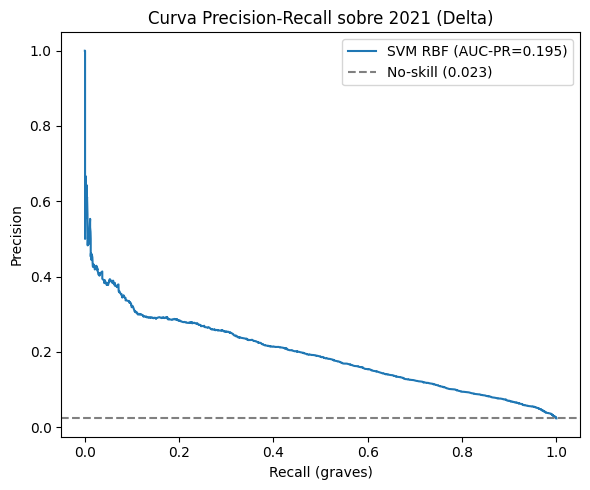

In [20]:
# --- Curva PR del mejor modelo (segun AUC-PR en CV) ---
metricas_cv = pd.DataFrame(filas_cv)
mejor_idx = metricas_cv["AUC-PR"].str.split().str[0].astype(float).idxmax()
mejor_nombre = metricas_cv.loc[mejor_idx, "modelo"]
mejor_pipe = mejores[mejor_nombre]
print("Mejor modelo segun AUC-PR:", mejor_nombre)

proba_2021 = mejor_pipe.predict_proba(X_2021)[:, 1]
precision, recall, _ = precision_recall_curve(y_2021, proba_2021)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"{mejor_nombre} (AUC-PR={pr_auc:.3f})")
plt.axhline(y_2021.mean(), color="gray", linestyle="--", label=f"No-skill ({y_2021.mean():.3f})")
plt.xlabel("Recall (graves)")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall sobre 2021 (Delta)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "curva_pr_2021.png"), dpi=150, bbox_inches="tight")
plt.show()

Matriz de confusion (mejor modelo, 2021) [[TN, FP], [FN, TP]]:
[[82264 15409]
 [  544  1783]]

Reporte de clasificacion (2021):
              precision    recall  f1-score   support

           0      0.993     0.842     0.912     97673
           1      0.104     0.766     0.183      2327

    accuracy                          0.840    100000
   macro avg      0.549     0.804     0.547    100000
weighted avg      0.973     0.840     0.895    100000



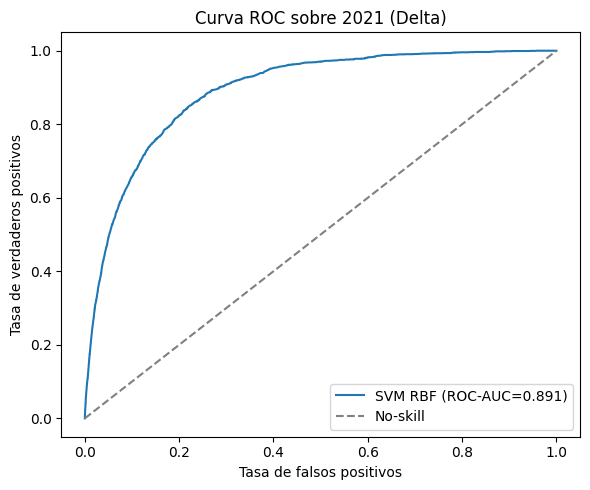

In [21]:
# --- Matriz de confusion y curva ROC del mejor modelo (criterio 7.4) ---
# Interpretacion de errores: el falso negativo (grave no detectado) es el costo mas alto.
y_pred_2021 = mejor_pipe.predict(X_2021)
cm = confusion_matrix(y_2021, y_pred_2021)
print("Matriz de confusion (mejor modelo, 2021) [[TN, FP], [FN, TP]]:")
print(cm)
print("\nReporte de clasificacion (2021):")
print(classification_report(y_2021, y_pred_2021, digits=3, zero_division=0))

fpr, tpr, _ = roc_curve(y_2021, proba_2021)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{mejor_nombre} (ROC-AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="No-skill")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC sobre 2021 (Delta)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "roc_2021.png"), dpi=150, bbox_inches="tight")
plt.show()

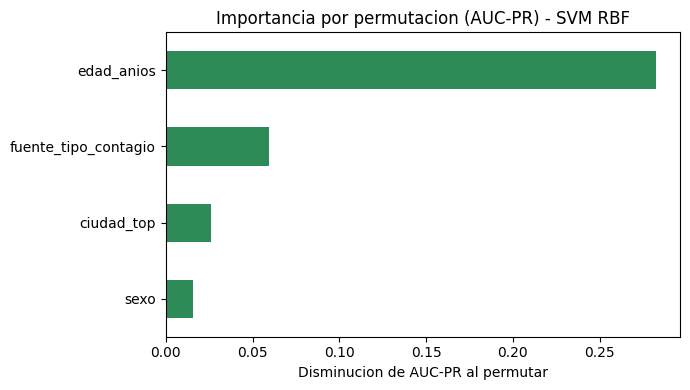

Importancias medias:
sexo                    0.015579
ciudad_top              0.026027
fuente_tipo_contagio    0.059670
edad_anios              0.282200


In [22]:
# --- Importancia de variables (permutacion) del mejor modelo ---
# Usamos un subconjunto para agilizar la permutacion
X_perm = X_2021.sample(min(2_000, len(X_2021)), random_state=SEED)
y_perm = y_2021.loc[X_perm.index]
pi = permutation_importance(mejor_pipe, X_perm, y_perm, scoring="average_precision",
                            n_repeats=10, random_state=SEED, n_jobs=-1)

importancias = pd.Series(pi.importances_mean, index=X_perm.columns).sort_values()
plt.figure(figsize=(7, 4))
importancias.plot(kind="barh", color="seagreen")
plt.title(f"Importancia por permutacion (AUC-PR) - {mejor_nombre}")
plt.xlabel("Disminucion de AUC-PR al permutar")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "importancia_permutacion.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Importancias medias:")
print(importancias.to_string())

## Resumen de decisiones metodologicas

- **Particion temporal**: train 2020; despliegue 2021 (Delta) y 2022 (Omicron).
- **Sin fuga**: preprocesamiento + SMOTE dentro del `Pipeline`, ajustados solo con el train de cada fold/particion; `ubicacion` excluida como predictor (contiene el desenlace).
- **Metricas por desbalance**: F1 y AUC-PR de la clase grave (priorizan detectar graves; el costo caro es el falso negativo).
- **Adaptacion del metodo**: datos reales colombianos (INS) + particion temporal + variables mixtas (codificadas) + comparacion multi-modelo y con Isolation Forest (cubre una limitacion del paper).

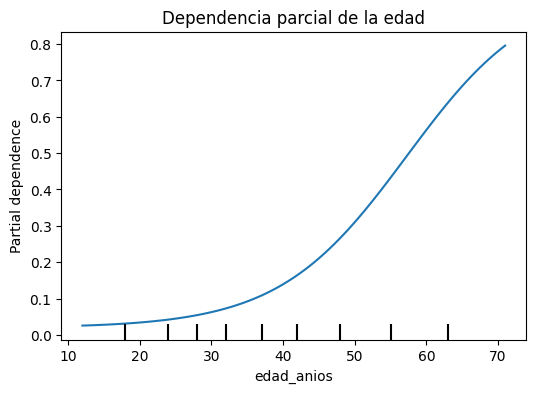

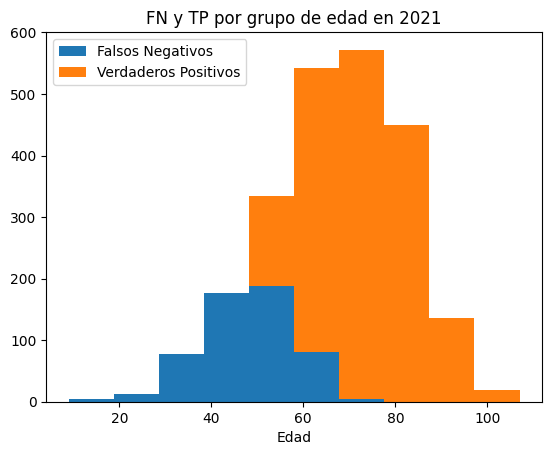

In [23]:
# --- Dependencia Parcial y Analisis de Falsos Negativos ---
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(mejor_pipe, X_2021.sample(10000, random_state=SEED), ['edad_anios'], ax=ax)
plt.title('Dependencia parcial de la edad')
plt.show()

# Falsos Negativos por grupo de edad
y_pred_2021 = mejor_pipe.predict(X_2021)
fn_mask = (y_2021 == 1) & (y_pred_2021 == 0)
tp_mask = (y_2021 == 1) & (y_pred_2021 == 1)
fn_edad = X_2021[fn_mask]['edad_anios']
tp_edad = X_2021[tp_mask]['edad_anios']

plt.hist([fn_edad, tp_edad], bins=10, label=['Falsos Negativos', 'Verdaderos Positivos'], stacked=True)
plt.legend()
plt.title('FN y TP por grupo de edad en 2021')
plt.xlabel('Edad')
plt.show()
